In [1]:
print("Hello Ml")

Hello Ml


In [1]:
import pandas as pd                          # for handling data like a table
import matplotlib.pyplot as plt             # for making graphs (the fun part)
from sklearn.datasets import load_iris      # iris dataset is built into sklearn, pretty convenient
from sklearn.model_selection import train_test_split   # splits data into train and test
from sklearn.neighbors import KNeighborsClassifier     # the actual ml algorithm i'm using
from sklearn.metrics import accuracy_score, classification_report  # to see how well it did

Cell 2 — Loading Data
python

In [2]:
# Load the dataset
iris = load_iris()

# Convert to a pandas DataFrame (like an Excel table)
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

# See the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
# How many rows and columns?
print("Shape:", df.shape)

# How many flowers of each species?
print("\nSpecies count:")
print(df['species'].value_counts())

# Basic statistics
print("\nBasic stats:")
df.describe()

Shape: (150, 5)

Species count:
species
0    50
1    50
2    50
Name: count, dtype: int64

Basic stats:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


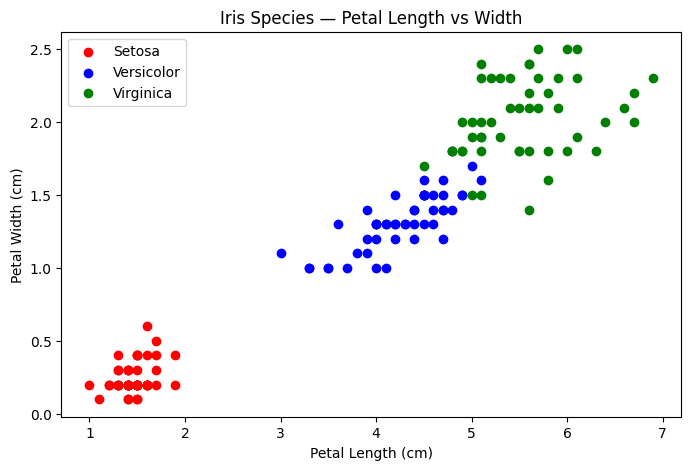

In [4]:
# plotting petal length vs petal width to see if species are visually separable
plt.figure(figsize=(8, 5))

colors = ['red', 'blue', 'green']
species_names = ['Setosa', 'Versicolor', 'Virginica']

for i in range(3):
    subset = df[df['species'] == i]
    plt.scatter(subset['petal length (cm)'],
                subset['petal width (cm)'],
                color=colors[i],
                label=species_names[i])

plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.title('Iris Species — Petal Length vs Width')
plt.legend()
plt.show()

In [5]:
# separating features (measurements) from labels (species names)
X = iris.data
y = iris.target

# Split: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


In [9]:
# Create the model
model = KNeighborsClassifier(n_neighbors=5)

# Train it
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
# Make predictions on test data
y_pred = model.predict(X_test)

# Accuracy score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Detailed report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [8]:
# Let's predict a flower we made up
new_flower = [[5.1, 3.5, 1.4, 0.2]]  # sepal_l, sepal_w, petal_l, petal_w

prediction = model.predict(new_flower)
print("Predicted species:", iris.target_names[prediction[0]])

Predicted species: setosa
